## Завдання 1
Побудуйте модель лінійної регресії на одній ознаці та порахуйте якість:
 * Завантажте датасет California Housing за допомогою fetch_california_housing.
 * Візьміть тільки одну ознаку MedInc і випадкові 5000 рядків.
 * Розділіть дані на навчальну і тестову вибірки в пропорції 80/20 з фіксованим параметром random_state=42 для відтворюваності результатів.
 * Навчіть модель LinearRegression.
 * Обчисліть коефіцієнт детермінації R² на тестовій вибірці.
 * Виведіть результат у таблиці:

| Модель | Ознака | R² |
| :--- | :--- | :--- |
| LinearRegression | MedInc | ... |


In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Target'] = housing.target

In [3]:
df_sample = df[['MedInc', 'Target']].sample(n=5000, random_state=42)

In [4]:
X = df_sample[['MedInc']]
y = df_sample['Target']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

In [8]:
results = pd.DataFrame({
    'Модель': ['LinearRegression'],
    'Ознака': ['MedInc'],
    'R²': [r2]
})

results.head()

,Модель,Ознака,R²
0,LinearRegression,MedInc,0.496119


## Завдання 2
Порівняйте якість моделі на одній ознаці та на двох ознаках:
 * Використовуйте датасет California Housing (випадкові 5000 рядків).
 * Побудуйте дві моделі:
     - тільки з ознакою MedInc;
     - з ознаками MedInc і AveRooms.
 * Розділіть дані на навчальну і тестову вибірки в пропорції 80/20 з фіксованим параметром random_state=42 для відтворюваності результатів.
 * Обчисліть R² на тестовій вибірці.
 * Виведіть результати в таблиці:

| Модель | Ознаки | R² |
| :--- | :--- | :--- |
| LinearRegression | MedInc | ... |
| LinearRegression | MedInc, AveRooms | ... |

In [9]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Target'] = housing.target
df_sample = df.sample(n=5000, random_state=42)

In [10]:
def train_and_evaluate(features):
    X = df_sample[features]
    y = df_sample['Target']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    return r2_score(y_test, y_pred)

In [11]:
r2_single = train_and_evaluate(['MedInc'])
r2_double = train_and_evaluate(['MedInc', 'AveRooms'])

In [ ]:
results = pd.DataFrame({
    'Модель': ['LinearRegression', 'LinearRegression'],
    'Ознаки': ['MedInc', 'MedInc, AveRooms'],
    'R²': [r2_single, r2_double]
}) 

In [13]:
results.head()

,Модель,Ознаки,R²
0,LinearRegression,MedInc,0.496119
1,LinearRegression,"MedInc, AveRooms",0.503710


## Завдання 3
Обчисліть кілька метрик помилки для однієї моделі:
 * Використовуйте датасет California Housing (випадкові 5000 рядків).
 * Розділіть дані на навчальну і тестову вибірки в пропорції 80/20 з фіксованим параметром random_state=42 для відтворюваності результатів.
 * Побудуйте модель лінійної регресії на ознаках MedInc і AveRooms.
 * На тестовій вибірці порахуйте:
     - MAE (mean_absolute_error).
     - MSE (mean_squared_error).
     - RMSE як np.sqrt(MSE).
     - R² (r2_score).
 * Оформіть результати в таблиці:

| Метрика | Значення |
| :--- | :--- |
| MAE | ... |
| MSE | ... |
| RMSE | ... |
| R² | ... |


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Target'] = housing.target
df_sample = df.sample(n=5000, random_state=42)

In [39]:
X = df_sample[['MedInc', 'AveRooms']]
y = df_sample['Target']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
y_pred = model.predict(X_test)

In [43]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [44]:
metrics_data = {
    'Метрика': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Значення': [mae, mse, rmse, r2]
}

In [45]:
results_df = pd.DataFrame(metrics_data)

In [46]:
results_df.head()

,Метрика,Значення
0,MAE,0.613654
1,MSE,0.670310
2,RMSE,0.818724
3,R²,0.503710


## Завдання 4
Побудуйте графік для порівняння реальних і передбачених значень:
 * Використовуйте датасет California Housing (випадкові 5000 рядків).
 * Розділіть дані на навчальну і тестову вибірки в пропорції 80/20 з фіксованим параметром random_state=42 для відтворюваності результатів.
 * Побудуйте модель лінійної регресії на ознаках MedInc і AveRooms.
 * Отримайте передбачення на тестовій вибірці.
 * Побудуйте scatter-графік: по осі X — y_test, по осі Y — y_pred.
 * Додайте лінію y = x (ідеальні передбачення).
 * Підпишіть осі та збережіть графік у файл.



In [47]:
import matplotlib.pyplot as plt

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Target'] = housing.target
df_sample = df.sample(n=5000, random_state=42)

In [49]:
X = df_sample[['MedInc', 'AveRooms']]
y = df_sample['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

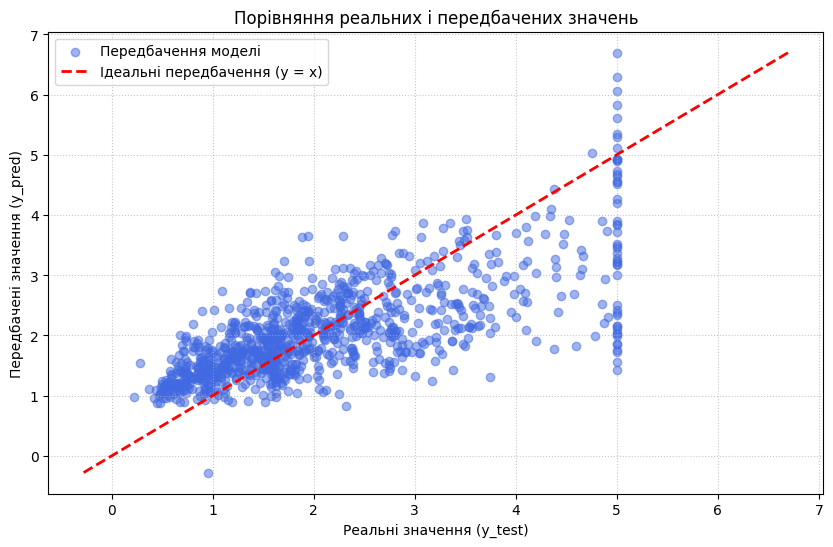

In [60]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue', label='Передбачення моделі')
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Ідеальні передбачення (y = x)')
plt.xlabel('Реальні значення (y_test)')
plt.ylabel('Передбачені значення (y_pred)')
plt.title('Порівняння реальних і передбачених значень')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('regression_comparison.png')
plt.show()